In [3]:
import pandas as pd
import numpy as np
import os

print("=" * 60)
print(" 🔗 MERGING CLASSIFICATION & REGRESSION SIGNALS")
print("=" * 60)

# กำหนด Path ของโฟลเดอร์ที่เก็บไฟล์ (ปรับให้ตรงกับที่คุณใช้งานจริง)
DIR_PATH = "../data/processed/splits"

# 1. โหลดข้อมูลของทั้ง 2 โมเดล (ตั้ง Date เป็น Index เพื่อให้รวมกันได้เป๊ะๆ)
clf_path = f"{DIR_PATH}/classification_signals_v2_full.csv"
reg_path = f"{DIR_PATH}/reg_predictions_v2_clean.csv"

if os.path.exists(clf_path) and os.path.exists(reg_path):
    # โหลด Classification
    df_clf = pd.read_csv(clf_path, parse_dates=['Date'], index_col='Date')
    
    # โหลด Regression
    df_reg = pd.read_csv(reg_path, parse_dates=['Date'], index_col='Date')
    
    # 2. รวมไฟล์เข้าด้วยกัน (Inner Join)
    # ดึงมาแค่ pred_return (จาก Regression) ไปแปะกับ Classification 
    df_combined = df_clf.join(df_reg[['pred_return', 'actual_return']], how='inner', rsuffix='_reg')
    
    # กรณีที่ actual_return มีชื่อซ้ำกัน ให้ใช้คอลัมน์ใดคอลัมน์หนึ่งแล้ว drop ส่วนเกินทิ้ง
    if 'actual_return_reg' in df_combined.columns:
        df_combined = df_combined.drop(columns=['actual_return_reg'])
    
    # 3. สร้างตรรกะ Signal Fusion -> ออกมาเป็นคอลัมน์ 'composite_direction'
    # ค่าเริ่มต้นคือ 0 (Hold)
    df_combined['composite_direction'] = 0 
    
    # เงื่อนไข Buy = 1 : Clf สั่ง Buy และ Reg มองว่าผลตอบแทนเป็นบวก
    condition_buy = (df_combined['signal'] == 'Buy') & (df_combined['pred_return'] > 0)
    df_combined.loc[condition_buy, 'composite_direction'] = 1
    
    # เงื่อนไข Sell = -1 : Clf สั่ง Sell และ Reg มองว่าผลตอบแทนเป็นลบ
    condition_sell = (df_combined['signal'] == 'Sell') & (df_combined['pred_return'] < 0)
    df_combined.loc[condition_sell, 'composite_direction'] = -1
    
    # ดึงคอลัมน์ 'split' จาก df_reg มาด้วย (ถ้ามี) เพื่อให้สามารถทำ Backtest แยก Train/Val/Test ได้
    if 'split' in df_reg.columns and 'split' not in df_combined.columns:
        df_combined['split'] = df_reg['split']
    
    # 4. บันทึกเป็นไฟล์ combined_predictions_full.csv
    save_path = f"{DIR_PATH}/combined_predictions_full.csv"
    df_combined.to_csv(save_path)
    
    print(f"✅ ไฟล์รวมสำเร็จและถูกบันทึกไว้ที่: {save_path}")
    print(f"📊 จำนวนข้อมูลทั้งหมด: {len(df_combined)} วัน")
    
    print("\n🔍 สรุปจำนวนสัญญาณที่ได้ (composite_direction):")
    print(df_combined['composite_direction'].value_counts().rename({0: 'Hold (0)', 1: 'Buy (1)', -1: 'Sell (-1)'}))
    
    print("\nตัวอย่างข้อมูล 5 บรรทัดแรก:")
    print(df_combined[['signal', 'pred_return', 'composite_direction', 'actual_return']].head())

else:
    print("❌ ไม่พบไฟล์ต้นฉบับ กรุณาตรวจสอบให้แน่ใจว่า:")
    print(f"1. มีไฟล์ {clf_path}")
    print(f"2. มีไฟล์ {reg_path}")

 🔗 MERGING CLASSIFICATION & REGRESSION SIGNALS
✅ ไฟล์รวมสำเร็จและถูกบันทึกไว้ที่: ../data/processed/splits/combined_predictions_full.csv
📊 จำนวนข้อมูลทั้งหมด: 563 วัน

🔍 สรุปจำนวนสัญญาณที่ได้ (composite_direction):
composite_direction
Hold (0)     470
Buy (1)       68
Sell (-1)     25
Name: count, dtype: int64

ตัวอย่างข้อมูล 5 บรรทัดแรก:
           signal  pred_return  composite_direction  actual_return
Date                                                              
2024-01-02   Sell     0.081149                    0      -1.462892
2024-01-03   Hold     0.111390                    0       0.398196
2024-01-04   Hold     0.106679                    0       0.004895
2024-01-05   Hold     0.096283                    0      -0.773602
2024-01-08    Buy     0.073640                    1      -0.009866


In [5]:
import pandas as pd
import numpy as np

def run_backtest(file_path, initial_capital=100000, signal_col='composite_direction', split_filter=None):
    # 1. โหลดข้อมูล
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
    # ถ้าต้องการ Backtest เฉพาะ test set ให้ระบุ split_filter='test'
    if split_filter:
        df = df[df['split'] == split_filter].copy()
    
    # 2. จำลองการเทรด (คำนวณ Strategy Return)
    # สมมติว่า actual_return มีหน่วยเป็น % (เช่น 1.23 หมายถึง 1.23%)
    df['strategy_return'] = df[signal_col] * df['actual_return']
    
    # คำนวณ Equity Curve แบบทบต้น (Compounding)
    df['equity_curve'] = initial_capital * (1 + df['strategy_return'] / 100).cumprod()
    
    # 3. คำนวณ Metrics ต่างๆ
    
    # หา Trade ที่เกิดขึ้นจริง (วันที่มี return ไม่เป็น 0 จากการเข้า Position)
    trades = df[df[signal_col] != 0].copy()
    winning_trades = trades[trades['strategy_return'] > 0]
    losing_trades = trades[trades['strategy_return'] < 0]
    
    total_trades = len(trades)
    buy_trades = len(trades[trades[signal_col] == 1])
    sell_trades = len(trades[trades[signal_col] == -1])
    
    win_rate = (len(winning_trades) / total_trades * 100) if total_trades > 0 else 0
    
    avg_win = winning_trades['strategy_return'].mean() if not winning_trades.empty else 0
    avg_loss = losing_trades['strategy_return'].mean() if not losing_trades.empty else 0
    
    gross_profit = winning_trades['strategy_return'].sum()
    gross_loss = abs(losing_trades['strategy_return'].sum())
    profit_factor = (gross_profit / gross_loss) if gross_loss != 0 else np.nan
    
    # Return & Equity
    final_equity = df['equity_curve'].iloc[-1]
    total_return_pct = ((final_equity / initial_capital) - 1) * 100
    
    # Max Drawdown
    df['peak'] = df['equity_curve'].cummax()
    df['drawdown'] = (df['equity_curve'] - df['peak']) / df['peak'] * 100
    max_drawdown = df['drawdown'].min()
    
    # Sharpe Ratio (สมมติว่าเทรด 252 วันต่อปี และ risk-free rate = 0)
    daily_returns = df['strategy_return'] / 100
    sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252) if daily_returns.std() != 0 else 0
    
    # Calmar Ratio (Annualized Return / Max Drawdown)
    days_in_backtest = (df['Date'].iloc[-1] - df['Date'].iloc[0]).days
    annualized_return = ((final_equity / initial_capital) ** (365.25 / days_in_backtest) - 1) * 100
    calmar_ratio = (annualized_return / abs(max_drawdown)) if max_drawdown != 0 else np.nan

    # 4. แสดงผลลัพธ์
    print("="*40)
    print("Backtest Performance Summary")
    print("="*40)
    print(f"  Total Return (%)         : {total_return_pct:.2f}")
    print(f"  Final Equity ($)         : {final_equity:.2f}")
    print(f"  Total Trades             : {total_trades}")
    print(f"  Win Rate (%)             : {win_rate:.2f}")
    print(f"  Avg Win (%)              : {avg_win:.4f}")
    print(f"  Avg Loss (%)             : {avg_loss:.4f}")
    print(f"  Profit Factor            : {profit_factor:.4f}")
    print(f"  Max Drawdown (%)         : {max_drawdown:.2f}")
    print(f"  Sharpe Ratio             : {sharpe_ratio:.4f}")
    print(f"  Calmar Ratio             : {calmar_ratio:.4f}")
    print(f"  BUY trades               : {buy_trades}")
    print(f"  SELL trades              : {sell_trades}")
    print("="*40)
    
    return df

# สมมติต้นทุนเริ่มต้นที่ $100,000 
result_df = run_backtest('../data/processed/splits/combined_predictions_full.csv', initial_capital=100000)



Backtest Performance Summary
  Total Return (%)         : 11.25
  Final Equity ($)         : 111246.46
  Total Trades             : 93
  Win Rate (%)             : 53.76
  Avg Win (%)              : 0.7337
  Avg Loss (%)             : -0.6421
  Profit Factor            : 1.4283
  Max Drawdown (%)         : -6.01
  Sharpe Ratio             : 0.8882
  Calmar Ratio             : 0.8146
  BUY trades               : 68
  SELL trades              : 25


⚠ ไม่พบคอลัมน์ 'split' ในข้อมูล จะทำการ Backtest ข้อมูลทั้งหมด
 REALISTIC BACKTEST PERFORMANCE
  Period                   : 2024-01-02 to 2026-03-27
  Initial Capital          : $100,000.00
  Final Equity             : $111,246.46
  Total Return             : 11.25%
---------------------------------------------
  Est. Total Trades        : 82 Trades
  Active Days (Buy/Sell)   : 68 / 25
  Win Rate                 : 53.76%
  Avg Win / Avg Loss       : 0.73% / -0.64%
  Profit Factor            : 1.43
---------------------------------------------
  Max Drawdown             : -6.01%
  Sharpe Ratio             : 0.89
  Calmar Ratio             : 0.81


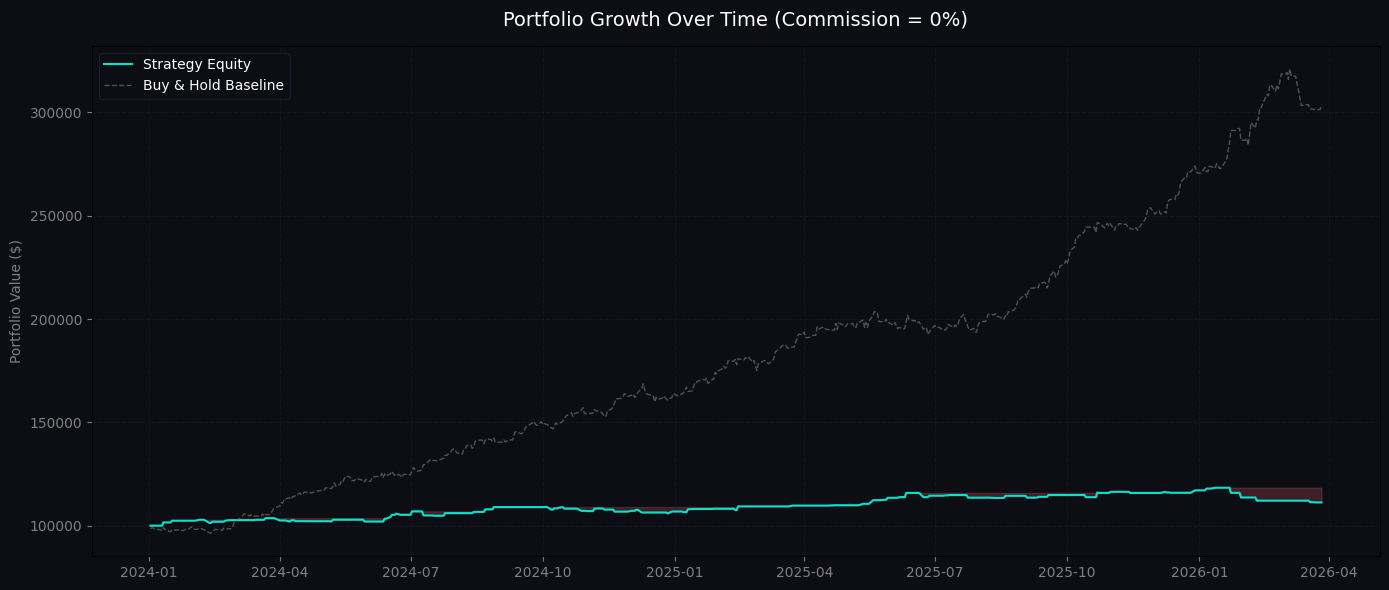

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def run_backtest(file_path, initial_capital=100000, signal_col='composite_direction', split_filter=None, commission_pct=0.05):
    """
    commission_pct: ค่าธรรมเนียมการเทรดต่อรอบ (เช่น 0.05 หมายถึง 0.05%)
    """
    # 1. โหลดข้อมูล
    if not os.path.exists(file_path):
        print(f"❌ ไม่พบไฟล์: {file_path}")
        return None
        
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
    if split_filter:
        if 'split' in df.columns:
            df = df[df['split'] == split_filter].copy().reset_index(drop=True)
        else:
            print(f"⚠ ไม่พบคอลัมน์ 'split' ในข้อมูล จะทำการ Backtest ข้อมูลทั้งหมด")
            
    if len(df) == 0:
        print("ไม่พบข้อมูลสำหรับทำ Backtest")
        return None
    
    # 2. จำลองการเทรด (มีค่าคอมมิชชั่น)
    # หาจำนวนการเปลี่ยนสถานะ (เช่น จาก 0 ไป 1 คือ 1 รอบ, จาก 1 ไป -1 คือ 2 รอบ)
    df['position_change'] = df[signal_col].diff().abs().fillna(abs(df[signal_col]))
    
    # คำนวณกำไร/ขาดทุนสุทธิ (หักค่าคอมมิชชั่นแล้ว)
    df['strategy_return'] = (df[signal_col] * df['actual_return']) - (df['position_change'] * commission_pct)
    
    # คำนวณ Equity Curve ทบต้น
    df['equity_curve'] = initial_capital * (1 + df['strategy_return'] / 100).cumprod()
    
    # 3. คำนวณ Metrics (พร้อมตัวดักจับ Error)
    trades = df[df[signal_col] != 0].copy()
    winning_trades = trades[trades['strategy_return'] > 0]
    losing_trades = trades[trades['strategy_return'] < 0]
    
    # ถ้ามีการถือสถานะข้ามวันยาวๆ ให้นับการเปลี่ยน Position เป็น 1 Trade
    total_trades = int(df['position_change'].sum() / 2) if df['position_change'].sum() > 0 else 0
    buy_days = len(trades[trades[signal_col] == 1])
    sell_days = len(trades[trades[signal_col] == -1])
    
    win_rate = (len(winning_trades) / len(trades) * 100) if len(trades) > 0 else 0
    
    avg_win = winning_trades['strategy_return'].mean() if not winning_trades.empty else 0
    avg_loss = losing_trades['strategy_return'].mean() if not losing_trades.empty else 0
    
    gross_profit = winning_trades['strategy_return'].sum()
    gross_loss = abs(losing_trades['strategy_return'].sum())
    profit_factor = (gross_profit / gross_loss) if gross_loss != 0 else (np.nan if gross_profit == 0 else float('inf'))
    
    final_equity = df['equity_curve'].iloc[-1]
    total_return_pct = ((final_equity / initial_capital) - 1) * 100
    
    # Max Drawdown
    df['peak'] = df['equity_curve'].cummax()
    df['drawdown'] = (df['equity_curve'] - df['peak']) / df['peak'] * 100
    max_drawdown = df['drawdown'].min()
    
    # Sharpe & Calmar Ratio
    daily_returns = df['strategy_return'] / 100
    std_dev = daily_returns.std()
    sharpe_ratio = (daily_returns.mean() / std_dev) * np.sqrt(252) if std_dev > 0 else 0
    
    days_in_backtest = (df['Date'].iloc[-1] - df['Date'].iloc[0]).days
    if days_in_backtest > 0:
        annualized_return = ((final_equity / initial_capital) ** (365.25 / days_in_backtest) - 1) * 100
        calmar_ratio = (annualized_return / abs(max_drawdown)) if max_drawdown < 0 else (np.nan if annualized_return == 0 else float('inf'))
    else:
        calmar_ratio = 0

    # 4. แสดงผลลัพธ์
    print("="*45)
    print(" REALISTIC BACKTEST PERFORMANCE")
    print("="*45)
    print(f"  Period                   : {df['Date'].iloc[0].date()} to {df['Date'].iloc[-1].date()}")
    print(f"  Initial Capital          : ${initial_capital:,.2f}")
    print(f"  Final Equity             : ${final_equity:,.2f}")
    print(f"  Total Return             : {total_return_pct:.2f}%")
    print("-" * 45)
    print(f"  Est. Total Trades        : {total_trades} Trades")
    print(f"  Active Days (Buy/Sell)   : {buy_days} / {sell_days}")
    print(f"  Win Rate                 : {win_rate:.2f}%")
    print(f"  Avg Win / Avg Loss       : {avg_win:.2f}% / {avg_loss:.2f}%")
    print(f"  Profit Factor            : {profit_factor:.2f}")
    print("-" * 45)
    print(f"  Max Drawdown             : {max_drawdown:.2f}%")
    print(f"  Sharpe Ratio             : {sharpe_ratio:.2f}")
    print(f"  Calmar Ratio             : {calmar_ratio:.2f}")
    print("="*45)
    
    # 5. พล็อตกราฟ Equity Curve
    plt.figure(figsize=(14, 6), facecolor='#0D0D14')
    plt.plot(df['Date'], df['equity_curve'], color='#00E5CC', lw=1.5, label='Strategy Equity')
    
    # เทียบกับ Buy & Hold (เส้นประสีเทา)
    bh_equity = initial_capital * (1 + df['actual_return'] / 100).cumprod()
    plt.plot(df['Date'], bh_equity, color='gray', lw=1.0, linestyle='--', alpha=0.6, label='Buy & Hold Baseline')
    
    plt.title(f'Portfolio Growth Over Time (Commission = {commission_pct}%)', color='white', fontsize=14, pad=15)
    plt.ylabel('Portfolio Value ($)', color='gray')
    plt.grid(color='#1E1E2E', linestyle='--', alpha=0.5)
    plt.gca().set_facecolor('#0D0D14')
    plt.tick_params(colors='gray')
    plt.legend(facecolor='#0D0D14', edgecolor='#1E1E2E', labelcolor='white')
    
    # เติมสีแดงในจุดที่เป็น Drawdown เพื่อให้ดูง่าย
    plt.fill_between(df['Date'], df['equity_curve'], df['peak'], color='#FF6B6B', alpha=0.2)
    plt.tight_layout()
    plt.show()
    
    return df

# เรียกใช้งาน: ตรวจสอบและรันบนไฟล์ที่รวมเรียบร้อยแล้ว
# แนะนำให้ลองใส่ split_filter='test' เพื่อดูประสิทธิภาพบนข้อมูล Test Set โดยเฉพาะ
result_df = run_backtest(
    file_path='../data/processed/splits/combined_predictions_full.csv', 
    initial_capital=100000, 
    split_filter='test',     # ทดสอบเฉพาะ Test Set
    commission_pct=0      # ค่าธรรมเนียมและ Slippage ไป-กลับ ต่อเทรด
)